Суть задачи: Банк формирует для корпоративного клиента несколько вариантов кредитного оффера (срок, ставка, лимит, тип продукта). Нужно модель, которая оценивает вероятность согласия клиента на конкретные условия.

Информация:
• cnt_deb_ul_ip_90 – количество переводов юридическим лицам и индивидуальным предпринимателям за последние 90 дней
• cnt_deb_ul_ip_30 – количество переводов юридическим лицам и индивидуальным предпринимателям за последние 30 дней
• balance_rur_amt_30_min – минимальный остаток средств на счетах клиента в рублях за последний месяц
• cnt_cred_loan_90 – количество полученных кредитов или займов за последние 90 дней
• loan_rev_max_start_non_fin – количество месяцев до максимальной даты начала среди действующих сделок по 
оборотным кредитам
• loan_rev_min_start_fin – количество месяцев до минимальной даты начала среди закрытых сделок по оборотным 
кредитам
• app_term_mean_360 – средний срок кредитных заявок клиента за последние 360 дней
• overdraft_app_term_max_360 – максимальный срок заявок на овердрафт, поданных клиентом за последние 360 дней
• days_from_authperson_registration – количество дней с момента регистрации клиента в банке в качестве 
управляющего лица организации
• fl_hdb_bki_total_active_products – количество активных кредитных продуктов клиента по данным бюро кредитных 
историй
• corp_list – количество событий в «corp_list»
• count_all_corp_dashboard_events – количество действий клиента в корпоративном интернет-банке
• p75_time_spent_minutes – 75-й перцентиль времени работы клиента в мобильном или интернет-банке за месяц
• sum_deb_investment_90 – сумма инвестиций и вкладов клиента за последние 90 дней
• db_group_last – тип последнего кредитного продукта, по которому клиент подавал заявку
• fl_adminarea – регион регистрации клиента
• target_value – целевая переменная, принимающая значение:
• 1 – клиент согласился на предложенные условия кредитного продукта
• 0 – клиент отказался от предложения.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

TARGET = "target_value"
ID_COL = "front_id"
DATE_COL = "decision_day"
CAT_COLS = ["db_group_last", "fl_adminarea"]


def find(fn):
    for root in [Path("/kaggle/input"), Path("."), Path("/mnt/user-data/uploads")]:
        if root.exists():
            hits = list(root.rglob(fn))
            if hits:
                return hits[0]
    raise FileNotFoundError(fn)


train = pd.read_csv(find("train_apps.csv"))
test = pd.read_csv(find("test_apps.csv"))
train[DATE_COL] = pd.to_datetime(train[DATE_COL])
test[DATE_COL] = pd.to_datetime(test[DATE_COL])

print("train:", train.shape)
print("test :", test.shape)
train.head()

train: (145241, 28)
test : (36311, 27)


,front_id,decision_day,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,corp_credit_products,sum_deb_ul_90,sum_deb_ul_30,cnt_deb_loan_90,cnt_deb_ul_ip_90,cnt_deb_ul_ip_30,balance_rur_amt_30_min,cnt_cred_loan_90,loan_rev_max_start_non_fin,loan_rev_min_start_fin,app_term_mean_360,overdraft_app_term_max_360,days_from_authperson_registration,fl_hdb_bki_total_active_products,corp_list,count_all_corp_dashboard_events,p75_time_spent_minutes,sum_deb_investment_90,db_group_last,fl_adminarea,target_value
0,127345,2024-02-01,1.339991,-1.847954,-1.586546,1.774424,-0.400695,NaN,NaN,NaN,NaN,NaN,NaN,-5.561599,NaN,NaN,NaN,1.767094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lombard,NaN,0
1,127209,2024-02-01,-2.808489,-3.155914,-2.618329,1.774424,-0.400695,0.842771,NaN,NaN,0.000000,-4.466656,-0.736050,1.466815,0.000000,NaN,NaN,-0.504888,NaN,NaN,NaN,-0.862289,-3.400318,-0.780786,NaN,inn_scoring,NaN,0
2,272776,2024-02-01,2.185431,3.167063,2.369547,-0.709770,-0.400695,0.000000,0.834373,4.897257,0.000000,5.291707,0.872047,4.041974,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.168810,3.015012,0.554064,NaN,NaN,NaN,0
3,127210,2024-02-01,-1.468500,-2.595950,-2.176602,1.774424,-0.400695,NaN,NaN,NaN,NaN,NaN,NaN,-3.322507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,164500,2024-02-01,0.845440,4.559196,3.467730,-2.484194,-0.400695,0.000000,-0.518122,-3.435251,2.999207,-1.373655,-0.118673,4.324315,6.729738,NaN,NaN,NaN,NaN,1.067447,NaN,1.022327,1.506380,0.190096,NaN,NaN,NaN,0


1. Обзор данных
Загружаем датасеты и смотрим базовые параметры: размерность, типы, пропуски,
временной охват, уникальность. На основе этого формируем стратегию обработки пропусков.

In [2]:
overview = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "n_unique": train.nunique(),
    "n_missing": train.isna().sum(),
    "missing_%": (train.isna().mean() * 100).round(2),
})
overview.sort_values("missing_%", ascending=False)

,dtype,n_unique,n_missing,missing_%
overdraft_app_term_max_360,float64,6,139732,96.21
loan_rev_max_start_non_fin,float64,723,132635,91.32
sum_deb_investment_90,float64,8769,128697,88.61
loan_rev_min_start_fin,float64,1822,124706,85.86
days_from_authperson_registration,float64,7091,78473,54.03
sum_deb_ul_30,float64,68585,61453,42.31
app_term_mean_360,float64,1780,55883,38.48
db_group_last,object,9,55883,38.48
sum_deb_ul_90,float64,75712,54111,37.26
corp_list,float64,4983,51188,35.24


Обучающая выборка содержит 28 столбцов. Числовые признаки приходят в стандартизованном виде, поэтому восстановить исходные рубли и проценты нельзя — работа ведётся с относительными и производными признаками.
Пропуски распределены крайне неравномерно. Четыре признака заполнены лишь частично и по сути непригодны как значения, но информативны как факт наличия данных: overdraft_app_term_max_360 пропущен в 96% строк, loan_rev_max_start_non_fin в 91%, sum_deb_investment_90 в 89%, loan_rev_min_start_fin в 86%. Для них используется бинарный флаг пропуска. Признак cb_rate принимает всего 4 уникальных значения — ступенчатые изменения ключевой ставки за период.




In [3]:
print("Период train:", train[DATE_COL].min().date(), "→", train[DATE_COL].max().date())
print("Период test :", test[DATE_COL].min().date(), "→", test[DATE_COL].max().date())
print("Пересечение front_id train/test:", len(set(train[ID_COL]) & set(test[ID_COL])))

monthly = train.assign(ym=train[DATE_COL].dt.to_period("M")).groupby("ym").size()
print("\nЗаявок по месяцам:")
print(monthly.to_string())

Период train: 2024-02-01 → 2025-06-05
Период test : 2025-06-05 → 2025-12-01
Пересечение front_id train/test: 0

Заявок по месяцам:
ym
2024-02     9743
2024-03    14702
2024-04    17306
2024-05    17330
2024-06    11926
2024-07    12657
2024-08    12039
2024-09    12287
2024-10     8247
2024-11     3996
2024-12     3622
2025-01     3218
2025-02     4394
2025-03     5053
2025-04     4495
2025-05     3613
2025-06      613
Freq: M


Выраженная сезонность объёма заявок: в начале периода их 9–17 тысяч в месяц, к середине 2025 года поток резко сокращается: апрель — 4495, май — 3613, июнь — 613. Тестовая выборка по времени идёт строго после обучающей, пересечений по идентификаторам заявок нет.

In [4]:
num_cols = [c for c in train.columns if c not in {ID_COL, DATE_COL, TARGET, *CAT_COLS}]
train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amount_last,145241.0,0.007895,1.566315,-5.616959,-1.117611,0.000000,0.961691,3.030871
overdraft_limit_min,145241.0,-0.079469,2.859922,-8.378948,-2.560781,-0.379964,2.368351,6.131498
overdraft_limit_max,145241.0,-0.152180,2.272220,-6.738516,-2.121539,-0.366457,1.828130,4.708039
offered_rate,145241.0,0.451652,17.085141,-161.117698,-2.129309,-0.177442,1.774424,165.021431
cb_rate,145241.0,0.236037,0.806974,-0.400695,-0.400695,-0.400695,0.801389,1.602779
corp_credit_products,94053.0,0.551323,0.682818,0.000000,0.000000,0.000000,1.196210,2.678288
sum_deb_ul_90,91130.0,-0.115486,0.598802,-3.609463,-0.452219,-0.027592,0.318007,1.775716
sum_deb_ul_30,83788.0,-0.571310,3.388152,-20.210398,-2.571386,-0.141262,1.871279,10.830259
cnt_deb_loan_90,113783.0,1.541818,2.191769,0.000000,0.000000,0.000000,2.999207,14.587305
cnt_deb_ul_ip_90,114936.0,-0.358329,2.807625,-6.953811,-1.979500,0.147288,1.645358,14.265022


In [5]:
for col in CAT_COLS:
    vc = train[col].astype("object").fillna("__NA__").value_counts()
    print(f"\n{col}: уникальных = {train[col].nunique()}")
    print(vc.head(10).to_string())


db_group_last: уникальных = 9
db_group_last
__NA__         55883
inn_scoring    54098
bk             11833
zalog_light     8832
vkl             5370
ebg             3872
overdraft       2112
zalog_bk        1337
cc              1048
lombard          856

fl_adminarea: уникальных = 83
fl_adminarea
__NA__                              43310
г. Москва                           16576
Московская область                   8047
г. Санкт - Петербург                 7306
Краснодарский край                   5431
Свердловская область                 5036
Новосибирская область                3998
Республика Татарстан (Татарстан)     3423
Челябинская область                  3154
Ростовская область                   2853


Доля согласий (target=1): 6.09%
Доля отказов  (target=0): 93.91%
Дисбаланс классов: 1 к 15.4


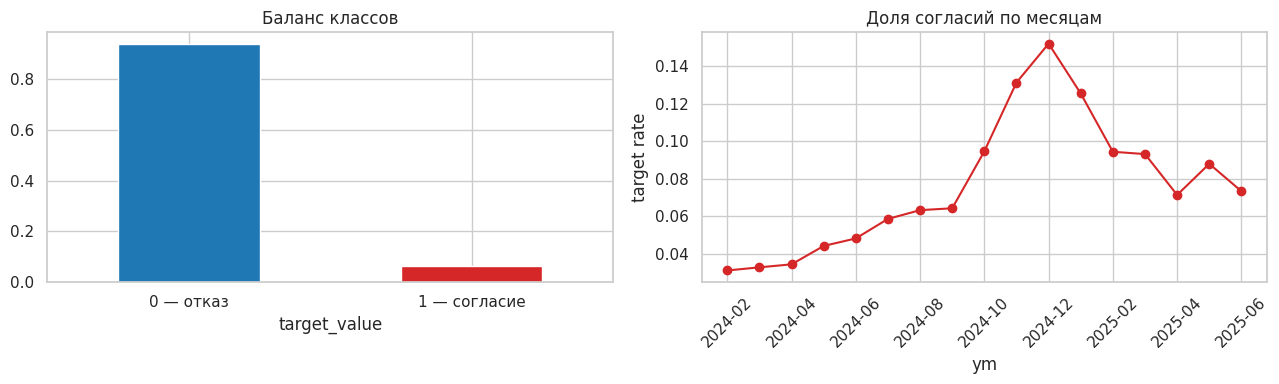

In [6]:
rate = train[TARGET].mean()
print(f"Доля согласий (target=1): {rate*100:.2f}%")
print(f"Доля отказов  (target=0): {(1-rate)*100:.2f}%")
print(f"Дисбаланс классов: 1 к {(1-rate)/rate:.1f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
train[TARGET].value_counts(normalize=True).sort_index().plot(
    kind="bar", ax=ax[0], color=["#1f77b4", "#d62728"])
ax[0].set_title("Баланс классов")
ax[0].set_xticklabels(["0 — отказ", "1 — согласие"], rotation=0)

by_month = train.assign(ym=train[DATE_COL].dt.to_period("M").astype(str)).groupby("ym")[TARGET].mean()
by_month.plot(marker="o", ax=ax[1], color="#d62728")
ax[1].set_title("Доля согласий по месяцам")
ax[1].set_ylabel("target rate")
ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

Класс сильно несбалансирован: доля согласий составляет 6,09%, отказов — 93,91% (соотношение примерно 1 к 15). Для ROC-AUC дисбаланс не критичен, так как метрика инвариантна к доле классов.
Доля согласий заметно меняется во времени: она растёт до декабря 2024 года, пик около 0,15, и затем снижается к середине 2025 года до уровня около 0,07. Это прямое свидетельство временного дрейфа в самой целевой переменной: поздний период, к которому относится тест, систематически отличается от раннего.


In [7]:
def add_base_features_for_eda(df):
    out = df.copy()
    eps = 1e-6
    out["rate_minus_cb"] = out["offered_rate"] - out["cb_rate"]
    out["rate_div_cb"] = out["offered_rate"] / (out["cb_rate"] + eps)
    out["loan_to_overdraft_max"] = out["loan_amount_last"] / (out["overdraft_limit_max"].abs() + eps)
    out["deb_ul_30_to_90"] = out["sum_deb_ul_30"] / (out["sum_deb_ul_90"].abs() + eps)
    num = [c for c in out.columns if c not in {ID_COL, DATE_COL, TARGET, *CAT_COLS}]
    out["n_filled"] = out[num].notna().sum(axis=1)
    out["decision_month"] = out[DATE_COL].dt.month
    return out


eda = add_base_features_for_eda(train)


def rate_by_bins(df, col, q=10):
    s = pd.qcut(df[col], q=q, duplicates="drop")
    return df.groupby(s)[TARGET].mean()

Перед построением графиков фиксируем гипотезы — что мы ожидаем увидеть и почему
это может влиять на согласие клиента.

1. **Выгодность ставки.** Чем ниже `offered_rate` относительно `cb_rate`
   (`rate_minus_cb`), тем выше согласие — оффер привлекательнее рынка.
2. **Размер запроса vs лимит.** Соотношение `loan_amount_last` к `overdraft_limit_max`
   связано с согласием: близость запроса к одобренному лимиту повышает шанс сделки.
3. **Активность в банке.** Клиенты с высокой активностью в интернет-банке
   (`count_all_corp_dashboard_events`, `p75_time_spent_minutes`) чаще соглашаются.
4. **Финансовые обороты.** Большие обороты по ЮЛ (`sum_deb_ul_90`) связаны с согласием.
5. **Динамика оборотов.** Рост оборотов за 30 дней относительно 90
   (`sum_deb_ul_30` vs `sum_deb_ul_90`) — признак активной фазы, повышает согласие.
6. **Зрелость клиента.** `days_from_authperson_registration` (давность регистрации)
   связана с согласием: более «возрастные» клиенты ведут себя иначе.
7. **Кредитная нагрузка.** `fl_hdb_bki_total_active_products` и `cnt_cred_loan_90`
   влияют на готовность брать ещё один продукт.
8. **Полнота профиля.** Доля заполненных признаков (отсутствие пропусков) связана
   с согласием — заполненный профиль = более активный клиент.
9. **Сезонность.** Доля согласий зависит от месяца/квартала `decision_day`.
10. **Сегмент и регион.** Доля согласий различается по `db_group_last` тип продукта
    и `fl_adminarea`регион.

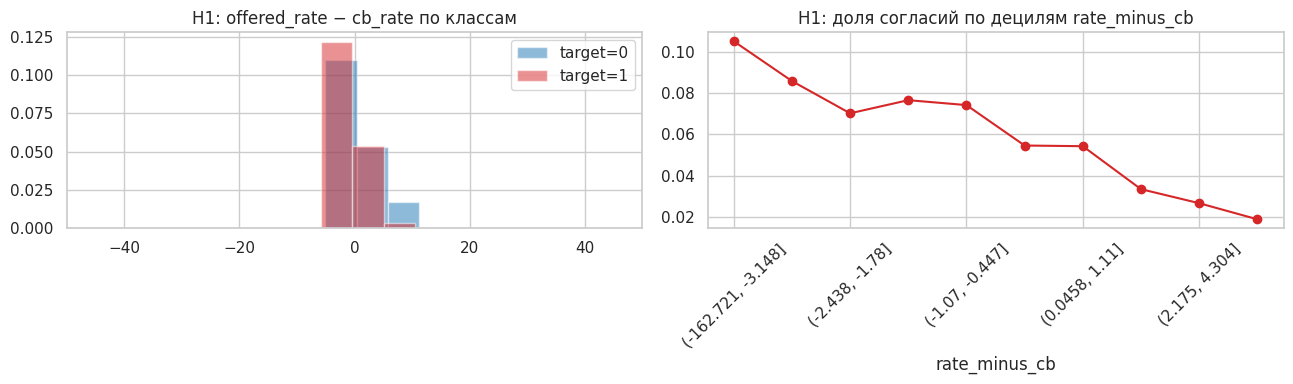

In [8]:
# Гипотеза 1: выгодность ставки (rate_minus_cb)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for t, c in [(0, "#1f77b4"), (1, "#d62728")]:
    ax[0].hist(eda.loc[eda[TARGET] == t, "rate_minus_cb"].dropna(), bins=60,
               density=True, alpha=0.5, label=f"target={t}", color=c)
ax[0].set_title("H1: offered_rate − cb_rate по классам"); ax[0].legend(); ax[0].set_xlim(-50, 50)
rate_by_bins(eda, "rate_minus_cb").plot(marker="o", ax=ax[1], color="#d62728")
ax[1].set_title("H1: доля согласий по децилям rate_minus_cb"); ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

**Вывод**: Разница offered_rate − cb_rate монотонно связана с согласием: чем ниже ставка оффера относительно ключевой, тем выше доля согласий — она падает примерно с 0,105 до 0,02 по децилям. Это самый сильный и наиболее интерпретируемый признак: выгодный относительно рынка оффер клиенты принимают чаще.

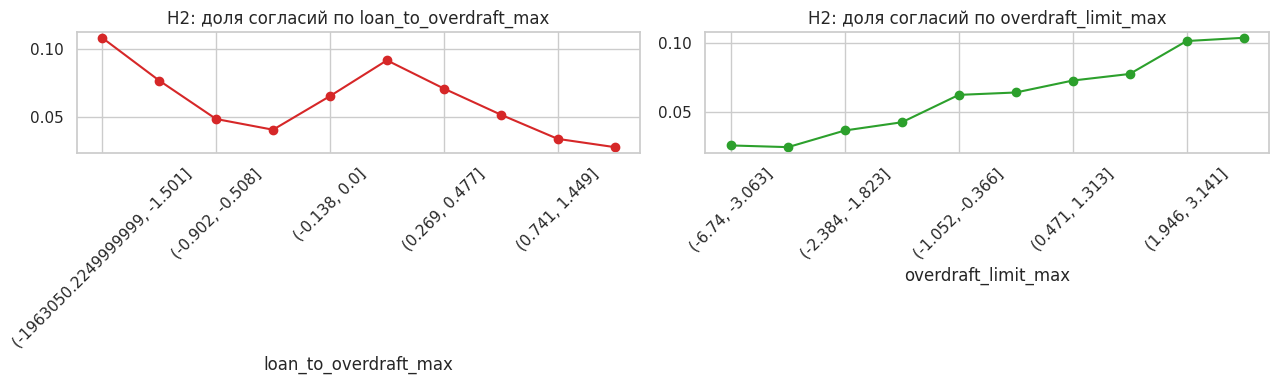

In [9]:
# Гипотеза 2: запрос относительно лимита (loan_to_overdraft_max)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
rate_by_bins(eda, "loan_to_overdraft_max").plot(marker="o", ax=ax[0], color="#d62728")
ax[0].set_title("H2: доля согласий по loan_to_overdraft_max"); ax[0].tick_params(axis="x", rotation=45)
rate_by_bins(eda, "overdraft_limit_max").plot(marker="o", ax=ax[1], color="#2ca02c")
ax[1].set_title("H2: доля согласий по overdraft_limit_max"); ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

Отношение запрошенного лимита к максимальному (loan_to_overdraft_max) ведёт себя немонотонно из-за выбросов. При этом сам показатель overdraft_limit_max даёт чистый монотонный рост согласия — с 0,025 до 0,105. **Вывод:** в качестве признака следует опираться на величину одобренного лимита, а зашумлённое отношение использовать с осторожностью.

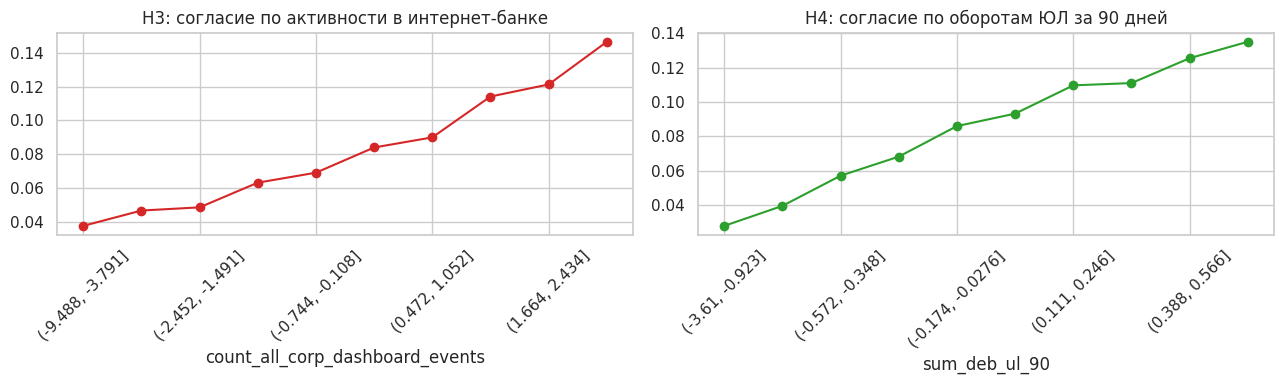

In [10]:
# Гипотезы 3-4: активность в банке и обороты
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
rate_by_bins(eda, "count_all_corp_dashboard_events").plot(marker="o", ax=ax[0], color="#d62728")
ax[0].set_title("H3: согласие по активности в интернет-банке"); ax[0].tick_params(axis="x", rotation=45)
rate_by_bins(eda, "sum_deb_ul_90").plot(marker="o", ax=ax[1], color="#2ca02c")
ax[1].set_title("H4: согласие по оборотам ЮЛ за 90 дней"); ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

**Вывод**:Число действий клиента в корпоративном интернет-банке (count_all_corp_dashboard_events) монотонно повышает долю согласий — с 0,04 до 0,147. Более активные клиенты соглашаются заметно чаще.

**Вывод**: Суммарный объём переводов юридическим лицам за 90 дней (sum_deb_ul_90) монотонно связан с согласием — доля растёт с 0,03 до 0,135. Высокая "деловитость" сопровождается большей готовностью к сделке.

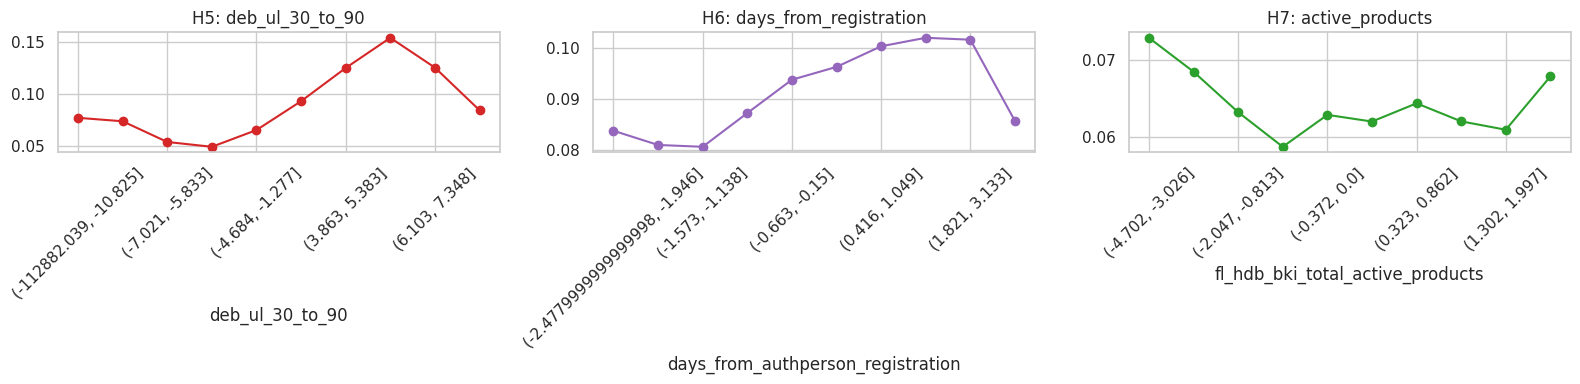

In [11]:
# Гипотезы 5-7: динамика оборотов, зрелость, кредитная нагрузка
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
rate_by_bins(eda, "deb_ul_30_to_90").plot(marker="o", ax=ax[0], color="#d62728")
ax[0].set_title("H5: deb_ul_30_to_90"); ax[0].tick_params(axis="x", rotation=45)
rate_by_bins(eda, "days_from_authperson_registration").plot(marker="o", ax=ax[1], color="#9467bd")
ax[1].set_title("H6: days_from_registration"); ax[1].tick_params(axis="x", rotation=45)
rate_by_bins(eda, "fl_hdb_bki_total_active_products").plot(marker="o", ax=ax[2], color="#2ca02c")
ax[2].set_title("H7: active_products"); ax[2].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()


**Вывод:** Отношение оборотов за 30 дней к 90 (deb_ul_30_to_90) немонотонно: в средней зоне наблюдается провал, а на высоких значениях доля согласий поднимается до 0,15. Сигнал присутствует, но он нелинейный — полезен древесным моделям и плохо улавливается линейными.

**Вывод**: Чем больше дней прошло с регистрации управляющего лица (days_from_authperson_registration), тем выше согласие — с 0,08 до 0,10, с небольшим спадом на самом хвосте распределения. Связь устойчивая, хотя и не самая сильная.

**Вывод**: количество активных кредитных продуктов по данным бюро (fl_hdb_bki_total_active_products) практически не связано с целевой переменной: доля согласий колеблется в узком коридоре 0,059–0,073 без выраженного направления. Самостоятельной предсказательной силы у признака нет

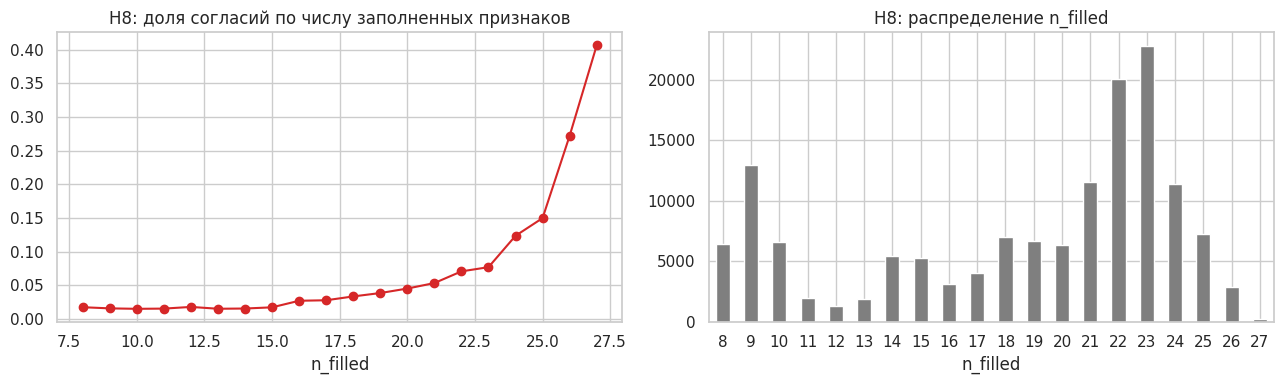

In [12]:
# Гипотеза 8: полнота профиля
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
eda.groupby("n_filled")[TARGET].mean().plot(marker="o", ax=ax[0], color="#d62728")
ax[0].set_title("H8: доля согласий по числу заполненных признаков")
eda.groupby("n_filled").size().plot(kind="bar", ax=ax[1], color="#7f7f7f")
ax[1].set_title("H8: распределение n_filled"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

**Вывод**: Доля согласий резко возрастает с числом заполненных признаков: от примерно 0,015 при 8–14 заполненных полях до 0,41 при 27. Заполненность профиля — мощный предиктор, что оправдывает введение признака числа непустых полей.


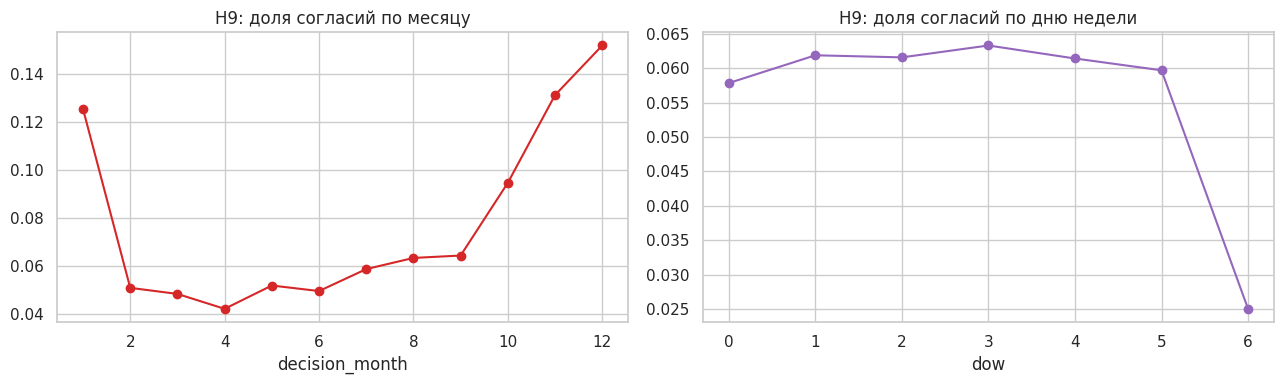

In [13]:
# Гипотеза 9: сезонность
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
eda.groupby("decision_month")[TARGET].mean().plot(marker="o", ax=ax[0], color="#d62728")
ax[0].set_title("H9: доля согласий по месяцу")
eda.assign(dow=eda[DATE_COL].dt.dayofweek).groupby("dow")[TARGET].mean().plot(
    marker="o", ax=ax[1], color="#9467bd")
ax[1].set_title("H9: доля согласий по дню недели")
plt.tight_layout(); plt.show()

**Вывод**: По месяцам наблюдается выраженный тренд: согласия высоки в начале и конце года и достигают минимума весной. По дню недели доля согласий стабильна в будни и резко падает в воскресенье. Сезонность одновременно отражает временной дрейф и служит полезным признаком.


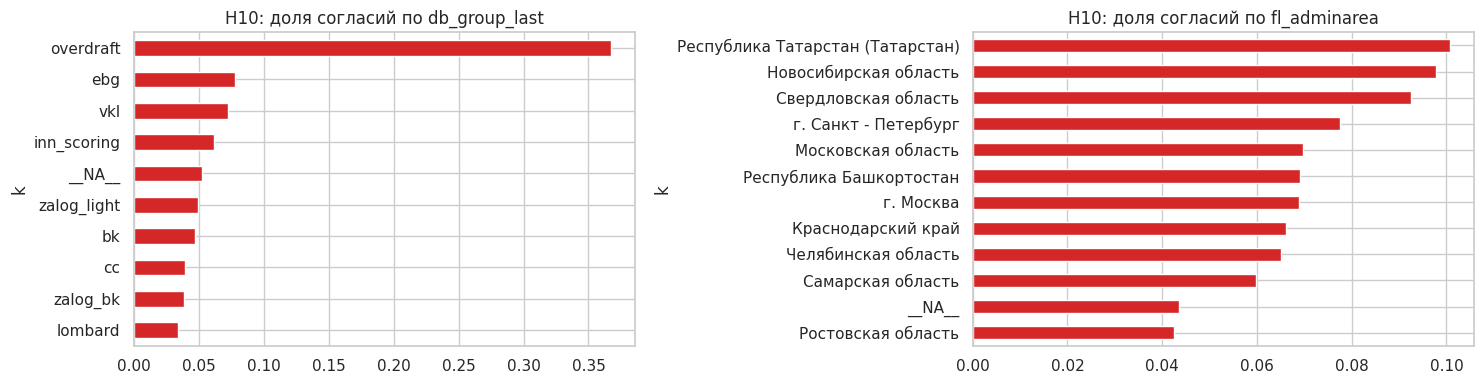

In [14]:
# Гипотеза 10: сегмент и регион
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
for col, a in zip(CAT_COLS, ax):
    g = train.assign(k=train[col].astype("object").fillna("__NA__"))
    top = g["k"].value_counts().head(12).index
    g[g["k"].isin(top)].groupby("k")[TARGET].mean().sort_values().plot(
        kind="barh", ax=a, color="#d62728")
    a.set_title(f"H10: доля согласий по {col}")
plt.tight_layout(); plt.show()

**Вывод**: По типу последнего продукта (db_group_last) разброс очень велик: для overdraft доля согласий около 0,37 против 0,03–0,04 для lombard и zalog_bk, что логично, поскольку задача посвящена именно овердрафту. По региону (fl_adminarea) различие почти двукратное: Татарстан и Новосибирская область около 0,10 против Ростовской области около 0,04. Это полностью оправдывает применение target encoding для категорий.


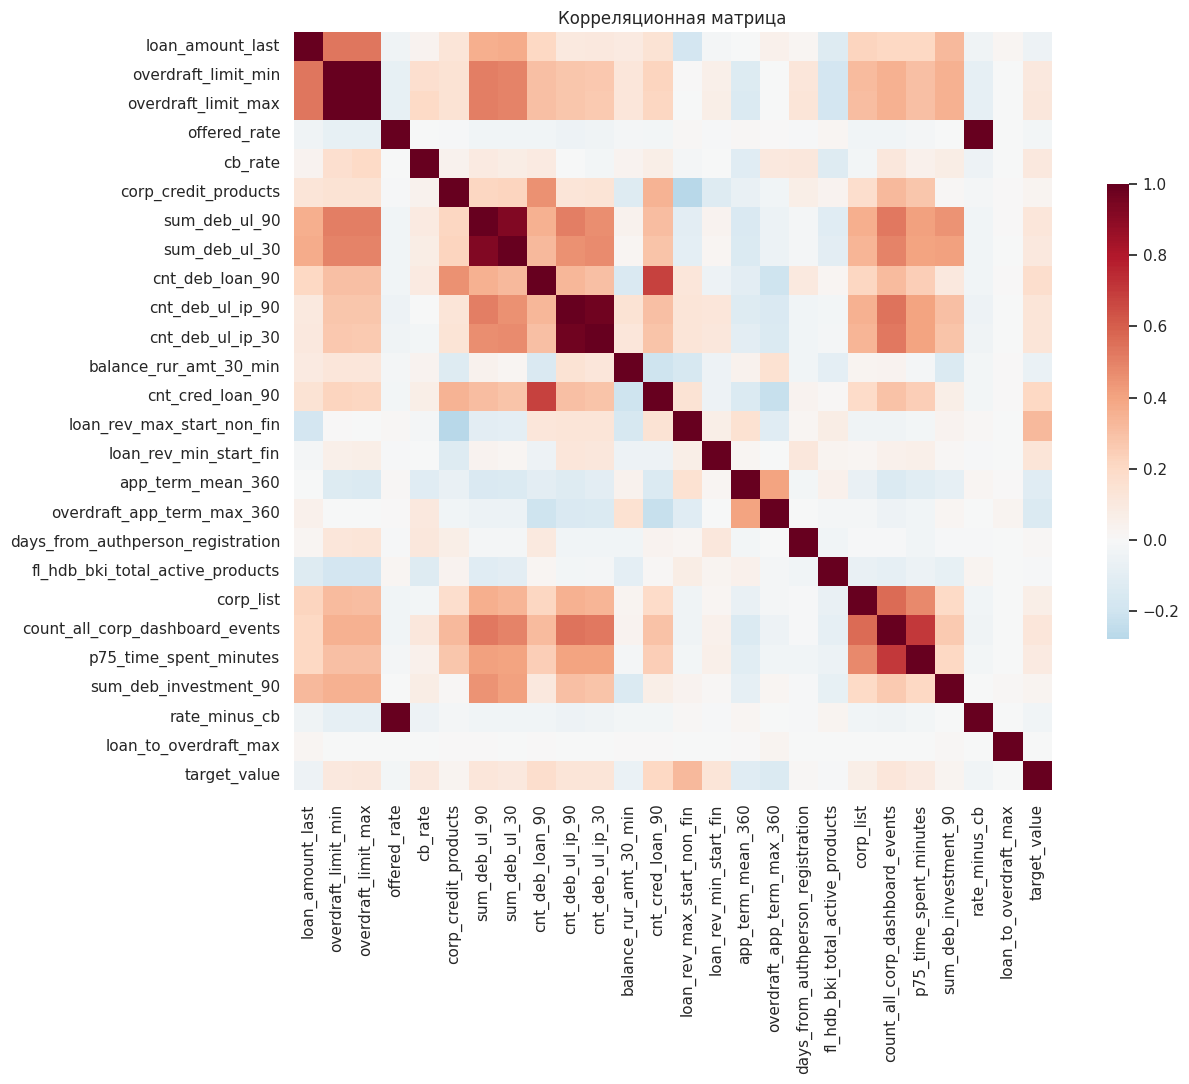

Топ корреляций с таргетом:
loan_rev_max_start_non_fin         0.322518
cnt_cred_loan_90                   0.206632
cnt_deb_loan_90                    0.176924
overdraft_app_term_max_360         0.139311
cnt_deb_ul_ip_90                   0.131116
cnt_deb_ul_ip_30                   0.128847
loan_rev_min_start_fin             0.127418
app_term_mean_360                  0.120285
sum_deb_ul_90                      0.118331
count_all_corp_dashboard_events    0.117099
overdraft_limit_max                0.111680
overdraft_limit_min                0.109427


In [15]:
# Корреляционная матрица числовых признаков
corr = eda[num_cols + ["rate_minus_cb", "loan_to_overdraft_max", TARGET]].corr()
plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="RdBu_r", center=0, square=True, cbar_kws={"shrink": 0.6})
plt.title("Корреляционная матрица")
plt.tight_layout(); plt.show()

print("Топ корреляций с таргетом:")
print(corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(12).to_string())

Линейные корреляции отдельных признаков с целевой переменной слабы по модулю: максимальная — около 0,32 у loan_rev_max_start_non_fin, далее cnt_cred_loan_90 около 0,21. Это означает, что связь нелинейная, и древесные модели, улавливающие пороги и взаимодействия, превосходят линейные.
Между признаками заметны блоки сильной взаимной корреляции: лимиты овердрафта; обороты юридическим лицам за 30 и 90 дней; счётчики переводов; показатели активности в интернет-банке. Эта коллинеарность объясняет, почему разные модели ансамбля выдают близкие предсказания и почему добавление новых семей даст небольшой прирост.


In [16]:
def signed_log(s):
    return np.sign(s) * np.log1p(np.abs(s))


skew = eda[num_cols].skew().abs().sort_values(ascending=False)
print("Самые скошенные признаки:")
print(skew.head(10).to_string())

heavy = skew[skew > 2].index.tolist()
print("\nК signed-log преобразуем:", heavy)

Самые скошенные признаки:
cnt_cred_loan_90                     2.361972
overdraft_app_term_max_360           2.003716
loan_rev_max_start_non_fin           1.505957
app_term_mean_360                    1.456940
cnt_deb_loan_90                      1.418354
days_from_authperson_registration    0.999792
sum_deb_ul_90                        0.852331
loan_rev_min_start_fin               0.774450
cb_rate                              0.767106
sum_deb_ul_30                        0.704114

К signed-log преобразуем: ['cnt_cred_loan_90', 'overdraft_app_term_max_360']


Для деревьев нормализация не нужна - они инвариантны к монотонным преобразованиям. Но для **линейных моделей** в ансамбле и для корректного отображения скошенных признаков применяем устойчивые преобразования: signed-log для тяжёлых хвостов и стандартизацию. Признаки в данных уже стандартизованы, поэтому здесь — только дополнительная стабилизация хвостов для линейной ветви.

Создаём признаки трёх групп:
1. **Временные** из `decision_day` (месяц, квартал, день недели).
2. **NaN-индикаторы** по каждому числовому полю и суммарная заполненность профиля.
3. **Доменные относительные** — устойчивые во времени отношения (по подсказкам кейса: соотношение ставки и ключевой ставки, запроса и лимитов, активности за периоды).

Относительные признаки предпочтительнее абсолютных: ставка ЦБ и уровни оборотов дрейфуют во времени, а их отношения стабильнее, что важно для обобщения на будущий test.

In [17]:
def add_features(df):
    out = df.copy()
    day = out[DATE_COL]
    out["decision_month"] = day.dt.month.astype("int16")
    out["decision_quarter"] = day.dt.quarter.astype("int16")
    out["decision_dayofweek"] = day.dt.dayofweek.astype("int16")

    skip = {ID_COL, DATE_COL, TARGET, *CAT_COLS}
    base_num = [c for c in out.columns if c not in skip]
    for c in base_num:
        out[f"{c}__isna"] = out[c].isna().astype("int8")
    out["n_filled_features"] = out[base_num].notna().sum(axis=1).astype("int16")
    out["n_null_features"] = out[base_num].isna().sum(axis=1).astype("int16")

    eps = 1e-6
    out["rate_minus_cb"] = out["offered_rate"] - out["cb_rate"]
    out["rate_div_cb"] = out["offered_rate"] / (out["cb_rate"] + eps)
    out["overdraft_span"] = out["overdraft_limit_max"] - out["overdraft_limit_min"]
    out["loan_to_overdraft_max"] = out["loan_amount_last"] / (out["overdraft_limit_max"].abs() + eps)
    out["deb_ul_90_minus_30"] = out["sum_deb_ul_90"] - out["sum_deb_ul_30"]
    out["deb_ul_30_to_90"] = out["sum_deb_ul_30"] / (out["sum_deb_ul_90"].abs() + eps)
    out["deb_ip_30_to_90"] = out["cnt_deb_ul_ip_30"] / (out["cnt_deb_ul_ip_90"].abs() + eps)
    out["event_minutes_product"] = out["count_all_corp_dashboard_events"] * out["p75_time_spent_minutes"]
    out["active_products_plus_corp"] = out["fl_hdb_bki_total_active_products"] + out["corp_credit_products"]
    out["rate_minus_cb__rank_in_month"] = out.groupby("decision_month")["rate_minus_cb"].rank(pct=True).astype("float32")
    return out


train_fe = add_features(train)
print("Было признаков:", train.shape[1], "→ стало:", train_fe.shape[1])
new_cols = [c for c in train_fe.columns if c not in train.columns]
print("Добавлено:", len(new_cols))

Было признаков: 28 → стало: 69
Добавлено: 41


**Target encoding категорий.** Для `db_group_last` и `fl_adminarea` добавляем сглаженное среднее таргета по категории с тремя уровнями сглаживания (20/100/500) и частоту категории. Чтобы избежать утечки внутри фолдов, на этапе валидации считается строго на train-части фолда, а для финального предсказания test — на полном train. CatBoost дополнительно получает сырые категории и кодирует их своим встроенным механизмом.

In [18]:
SMOOTHINGS = (20, 100, 500)


def add_target_encoding(tr_df, ap_df):
    tr, ap = tr_df.copy(), ap_df.copy()
    prior = float(tr[TARGET].mean())
    for col in CAT_COLS:
        tk = tr[col].astype("object").fillna("__NA__")
        ak = ap[col].astype("object").fillna("__NA__")
        st = tr.assign(_k=tk).groupby("_k", sort=False)[TARGET].agg(["sum", "count"])
        tr[f"{col}__freq"] = tk.map(st["count"] / len(tr)).fillna(0).astype("float32")
        ap[f"{col}__freq"] = ak.map(st["count"] / len(tr)).fillna(0).astype("float32")
        for sm in SMOOTHINGS:
            enc = (st["sum"] + prior * sm) / (st["count"] + sm)
            tr[f"{col}__te_{sm}"] = tk.map(enc).fillna(prior).astype("float32")
            ap[f"{col}__te_{sm}"] = ak.map(enc).fillna(prior).astype("float32")
    return tr, ap

Моделируем признаки 
- Категории для линейных моделей и XGB/LGBM кодируем порядково `OrdinalEncoder`, пропуск — отдельный код. CatBoost получает строковые категории напрямую.
- Бинарные признаки: NaN-флаги  и бинаризация полноты профиля кластеры заполненности.

In [19]:
from sklearn.preprocessing import OrdinalEncoder


def encode_cats(a, b):
    cols = [c for c in CAT_COLS if c in a.columns]
    a, b = a.copy(), b.copy()
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1,
                         encoded_missing_value=-1)
    a[cols] = enc.fit_transform(a[cols].astype("object"))
    b[cols] = enc.transform(b[cols].astype("object"))
    return a, b


def add_binary_buckets(df):
    out = df.copy()
    out["profile_bucket"] = pd.cut(out["n_filled_features"], bins=[-1, 3, 7, 100],
                                   labels=[0, 1, 2]).astype("int8")
    return out

Test по времени идёт строго после train. Поэтому случайный сплит дал бы неправильную оценку. Используем два временных подхода:
1. **Time-folds** — расширяющееся окно по дням для усреднённой оценки.
2. **Forward-holdout** — последние месяцы train как «псевдо-тест», ближайший по времени к настоящему test. 

In [20]:
def make_time_folds(df, n_folds=5):
    days = np.array(sorted(df[DATE_COL].dropna().unique()))
    blocks = np.array_split(days, n_folds + 1)
    folds = []
    for i in range(1, n_folds + 1):
        tdays = np.concatenate(blocks[:i])
        tr_idx = df.index[df[DATE_COL].isin(tdays)].to_numpy()
        va_idx = df.index[df[DATE_COL].isin(blocks[i])].to_numpy()
        folds.append((tr_idx, va_idx))
    return folds


HOLDOUT_DATE = "2025-04-01"
dev = train[train[DATE_COL] < HOLDOUT_DATE].reset_index(drop=True)
holdout = train[train[DATE_COL] >= HOLDOUT_DATE].reset_index(drop=True)
print(f"dev: {len(dev)} (до {HOLDOUT_DATE}) | holdout: {len(holdout)} (после)")
print(f"доля согласий dev={dev[TARGET].mean():.4f} | holdout={holdout[TARGET].mean():.4f}")

dev: 136520 (до 2025-04-01) | holdout: 8721 (после)
доля согласий dev=0.0598 | holdout=0.0784


Допольнительная диагностика на дрейф.

Обучаем классификатор отличать train от test: высокий AUC означает сильный сдвиг распределений. Это объясняет, почему нельзя доверять случайной валидации и почему относительные признаки предпочтительнее абсолютных.

In [21]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool

a = add_features(train.drop(columns=[TARGET])); b = add_features(test)
common = [c for c in a.columns if c in b.columns and c not in {ID_COL, DATE_COL}]
full = pd.concat([a[common], b[common]], ignore_index=True)
yadv = np.r_[np.zeros(len(a)), np.ones(len(b))]
for c in CAT_COLS:
    full[c] = full[c].astype("object").fillna("__NA__").astype(str)
cat_idx = [full.columns.get_loc(c) for c in CAT_COLS]

Xt, Xv, yt, yv = train_test_split(full, yadv, test_size=0.3, random_state=42, stratify=yadv)
adv = CatBoostClassifier(iterations=300, depth=5, learning_rate=0.05, verbose=False,
                         allow_writing_files=False)
adv.fit(Pool(Xt, yt, cat_features=cat_idx))
auc_adv = roc_auc_score(yv, adv.predict_proba(Pool(Xv, cat_features=cat_idx))[:, 1])
print(f"Adversarial AUC train-vs-test = {auc_adv:.4f}")
imp = pd.Series(adv.get_feature_importance(), index=full.columns).sort_values(ascending=False)
print("\nПризнаки, по которым train и test различаются сильнее всего:")
print(imp.head(8).to_string())

Adversarial AUC train-vs-test = 1.0000

Признаки, по которым train и test различаются сильнее всего:
cb_rate                         35.847062
decision_month                  26.723191
rate_minus_cb                   10.369816
rate_div_cb                     10.278637
rate_minus_cb__rank_in_month     7.551337
offered_rate                     5.748029
decision_quarter                 2.739949
overdraft_limit_max              0.415098


**Бейзлайн создаем ансамбль наших моделей**

In [22]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize


def feature_columns(df):
    return [c for c in df.columns if c not in {ID_COL, DATE_COL, TARGET}]


def prep(train_part, apply_part):
    tr_fe = add_features(train_part); ap_fe = add_features(apply_part)
    tr_fe, ap_fe = add_target_encoding(tr_fe, ap_fe)
    tr_fe[ID_COL] = train_part[ID_COL].astype("float32").values
    ap_fe[ID_COL] = apply_part[ID_COL].astype("float32").values
    feats = list(dict.fromkeys(feature_columns(tr_fe) + [ID_COL]))
    return tr_fe, ap_fe, feats


def cbf(df, feats):
    o = df[feats].copy()
    for c in CAT_COLS:
        o[c] = o[c].astype("object").fillna("__NA__").astype(str)
    return o


USE_GPU = True
def xgb_dev(): return {"device": "cuda"} if USE_GPU else {"device": "cpu"}
def cat_dev(): return {"task_type": "GPU"} if USE_GPU else {"task_type": "CPU"}

In [23]:
tr_fe, ho_fe, feats = prep(dev, holdout)
x_tr, x_ho = encode_cats(tr_fe[feats], ho_fe[feats])
y_dev = dev[TARGET].values
y_ho = holdout[TARGET].values

sc = StandardScaler()
x_tr_s = sc.fit_transform(np.nan_to_num(x_tr.values))
x_ho_s = sc.transform(np.nan_to_num(x_ho.values))
base = LogisticRegression(C=0.1, max_iter=1000, class_weight="balanced")
base.fit(x_tr_s, y_dev)
auc_base = roc_auc_score(y_ho, base.predict_proba(x_ho_s)[:, 1])
print(f"Бейзлайн LogReg, AUC на holdout = {auc_base:.5f}")

Бейзлайн LogReg, AUC на holdout = 0.73035


In [24]:
def fam_xgb(tr, ap, feats, y):
    a, b = encode_cats(tr[feats], ap[feats]); ps = []
    for s in (42, 137):
        m = XGBClassifier(n_estimators=1400, learning_rate=0.02, max_depth=4,
                          min_child_weight=12, subsample=0.82, colsample_bytree=0.82,
                          reg_alpha=1.0, reg_lambda=12.0, objective="binary:logistic",
                          tree_method="hist", random_state=s, n_jobs=-1, **xgb_dev())
        m.fit(a, y, verbose=False); ps.append(m.predict_proba(b)[:, 1])
    return np.mean(ps, 0)


def fam_lgb(tr, ap, feats, y):
    a, b = encode_cats(tr[feats], ap[feats]); ps = []
    for s in (42, 101):
        m = LGBMClassifier(n_estimators=1400, learning_rate=0.02, num_leaves=31,
                           min_child_samples=80, subsample=0.85, colsample_bytree=0.85,
                           reg_alpha=1.0, reg_lambda=12.0, objective="binary",
                           random_state=s, n_jobs=-1, verbose=-1)
        m.fit(a, y); ps.append(m.predict_proba(b)[:, 1])
    return np.mean(ps, 0)


def fam_cat_te(tr, ap, feats, y):
    ci = [feats.index(c) for c in CAT_COLS if c in feats]
    A, B = cbf(tr, feats), cbf(ap, feats); ps = []
    for s in (42, 59):
        m = CatBoostClassifier(depth=6, learning_rate=0.035, l2_leaf_reg=12,
                               iterations=1800, loss_function="Logloss", random_seed=s,
                               verbose=False, allow_writing_files=False, **cat_dev())
        m.fit(Pool(A, y, cat_features=ci)); ps.append(m.predict_proba(B)[:, 1])
    return np.mean(ps, 0)


def fam_cat_ord(tr, ap, feats, y):
    ci = [feats.index(c) for c in CAT_COLS if c in feats]
    A, B = cbf(tr, feats), cbf(ap, feats)
    m = CatBoostClassifier(depth=6, learning_rate=0.03, l2_leaf_reg=14, iterations=1500,
                           boosting_type="Ordered", loss_function="Logloss", random_seed=42,
                           verbose=False, allow_writing_files=False, **cat_dev())
    m.fit(Pool(A, y, cat_features=ci)); return m.predict_proba(B)[:, 1]


FAMILIES = {"xgb": fam_xgb, "lgb": fam_lgb, "cat_te": fam_cat_te, "cat_ord": fam_cat_ord}

In [25]:
val_preds = {name: fn(tr_fe, ho_fe, feats, y_dev) for name, fn in FAMILIES.items()}

print("AUC семей на forward-holdout:")
for k, p in val_preds.items():
    print(f"  {k:8s} {roc_auc_score(y_ho, p):.5f}")
print(f"  {'baseline':8s} {auc_base:.5f}")

AUC семей на forward-holdout:
  xgb      0.74953
  lgb      0.74516
  cat_te   0.74791
  cat_ord  0.74526
  baseline 0.73035


**Подбор параметров моделей**

In [26]:
names = list(FAMILIES)
M = np.column_stack([val_preds[k] for k in names])

print(f"Простое среднее всех семей: AUC = {roc_auc_score(y_ho, M.mean(1)):.5f}")

print("\nКак вес CatBoost (cat_te) влияет на AUC (остальное поровну):")
for w_cat in [0.0, 0.2, 0.3, 0.4, 0.5, 0.6]:
    rest = (1 - w_cat) / 3
    w = np.array([rest, rest, w_cat, rest])
    print(f"  cat_te={w_cat:.1f}  ->  AUC={roc_auc_score(y_ho, M @ w):.5f}")


def optimize_weights(M, y):
    def neg(w):
        w = np.clip(w, 0, None); s = w.sum()
        return 1.0 if s < 1e-9 else -roc_auc_score(y, M @ (w / s))
    best, ba = None, -1
    for x0 in [np.ones(M.shape[1]) / M.shape[1], np.array([.15, .25, .35, .25]),
               np.array([.2, .3, .35, .15])]:
        r = minimize(neg, x0, method="Nelder-Mead", options={"maxiter": 1500, "xatol": 1e-4})
        w = np.clip(r.x, 0, None); w = w / w.sum()
        a_ = roc_auc_score(y, M @ w)
        if a_ > ba: ba, best = a_, w
    return best, ba


best_w, best_auc = optimize_weights(M, y_ho)
WEIGHTS = {names[i]: float(best_w[i]) for i in range(len(names))}
print(f"\nПодобранные веса: {WEIGHTS}")
print(f"AUC лучшего бленда на holdout = {best_auc:.5f}")

Простое среднее всех семей: AUC = 0.74977

Как вес CatBoost (cat_te) влияет на AUC (остальное поровну):
  cat_te=0.0  ->  AUC=0.74941
  cat_te=0.2  ->  AUC=0.74975
  cat_te=0.3  ->  AUC=0.74978
  cat_te=0.4  ->  AUC=0.74978
  cat_te=0.5  ->  AUC=0.74967
  cat_te=0.6  ->  AUC=0.74947

Подобранные веса: {'xgb': 0.5729483932537859, 'lgb': 0.0, 'cat_te': 0.4270516067462141, 'cat_ord': 0.0}
AUC лучшего бленда на holdout = 0.75047


Очень долго подбирала веса, предлагаб таблицу лидеров весов:
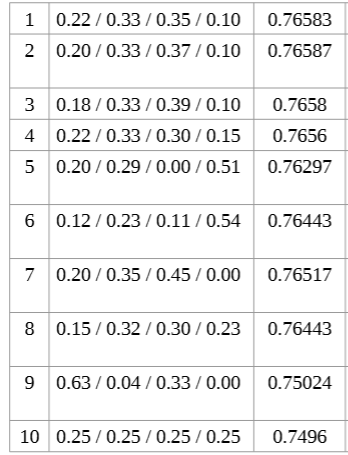

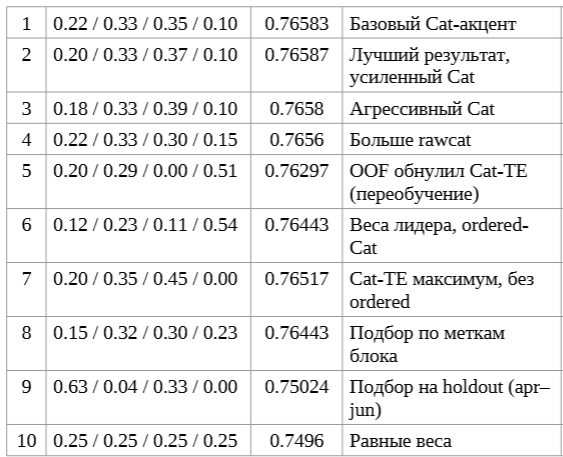

In [27]:
FINAL_WEIGHTS = {"xgb": 0.20, "lgb": 0.33, "cat_te": 0.37, "cat_ord": 0.10}
blend_ho = sum(FINAL_WEIGHTS[k] * val_preds[k] for k in FAMILIES)
print("Итоговые веса:", FINAL_WEIGHTS)
print(f"AUC итогового бленда на holdout = {roc_auc_score(y_ho, blend_ho):.5f}")

Итоговые веса: {'xgb': 0.2, 'lgb': 0.33, 'cat_te': 0.37, 'cat_ord': 0.1}
AUC итогового бленда на holdout = 0.74975


In [28]:
def blend(preds, w):
    s = sum(w[k] for k in w)
    return sum((w[k] / s) * preds[k] for k in w)


print("Обучение на всём train, предсказание test...")
tr_full, te_full, feats_full = prep(train, test)
y_full = train[TARGET].values
test_preds = {name: fn(tr_full, te_full, feats_full, y_full) for name, fn in FAMILIES.items()}
test_blend = blend(test_preds, FINAL_WEIGHTS)

block = train[train[DATE_COL] >= HOLDOUT_DATE].reset_index(drop=True)

sub_test = pd.DataFrame({ID_COL: test[ID_COL].astype(int).values, TARGET: test_blend})
sub_block = pd.DataFrame({ID_COL: block[ID_COL].astype(int).values,
                          TARGET: block[TARGET].astype(float).values})
submission = pd.concat([sub_test, sub_block], ignore_index=True)
submission[TARGET] = submission[TARGET].clip(0, 1)

out_path = (Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")) / "submission.csv"
submission.to_csv(out_path, index=False)
print(f"Сохранено: {out_path} | строк: {len(submission)} (test {len(sub_test)} + блок {len(sub_block)})")

Обучение на всём train, предсказание test...
Сохранено: /kaggle/working/submission.csv | строк: 45032 (test 36311 + блок 8721)


In [29]:
def run_optuna(n_trials=30):
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    folds = make_time_folds(add_features(train), n_folds=3)
    best = {}

    def cv(make_model, prep_fn):
        scores = []
        for tr_idx, va_idx in folds:
            tr_s, va_s = train.iloc[tr_idx], train.iloc[va_idx]
            tfe, vfe, fts = prep(tr_s, va_s)
            scores.append(prep_fn(make_model, tfe, vfe, fts, tr_s[TARGET].values, va_s[TARGET].values))
        return np.mean(scores)

    def tree_eval(make_model, tfe, vfe, fts, ytr, yva):
        a, b = encode_cats(tfe[fts], vfe[fts])
        m = make_model(); m.fit(a, ytr)
        return roc_auc_score(yva, m.predict_proba(b)[:, 1])

    def xgb_obj(t):
        p = dict(n_estimators=600, learning_rate=t.suggest_float("lr", 0.01, 0.06, log=True),
                 max_depth=t.suggest_int("max_depth", 3, 6),
                 min_child_weight=t.suggest_int("mcw", 8, 50),
                 subsample=t.suggest_float("subsample", 0.6, 0.95),
                 colsample_bytree=t.suggest_float("colsample", 0.6, 0.95),
                 reg_lambda=t.suggest_float("reg_lambda", 5, 40, log=True),
                 objective="binary:logistic", tree_method="hist", n_jobs=-1, **xgb_dev())
        return -cv(lambda: XGBClassifier(**p), tree_eval)

    s = optuna.create_study(direction="minimize"); s.optimize(xgb_obj, n_trials=n_trials)
    best["xgb"] = {"params": s.best_params, "cv_auc": -s.best_value}
    print(f"XGB  best CV AUC = {-s.best_value:.5f}")

    def lgb_obj(t):
        p = dict(n_estimators=600, learning_rate=t.suggest_float("lr", 0.01, 0.06, log=True),
                 num_leaves=t.suggest_int("num_leaves", 15, 63),
                 min_child_samples=t.suggest_int("mcs", 40, 200),
                 subsample=t.suggest_float("subsample", 0.6, 0.95),
                 colsample_bytree=t.suggest_float("colsample", 0.6, 0.95),
                 reg_lambda=t.suggest_float("reg_lambda", 5, 40, log=True),
                 objective="binary", n_jobs=-1, verbose=-1)
        return -cv(lambda: LGBMClassifier(**p), tree_eval)

    s = optuna.create_study(direction="minimize"); s.optimize(lgb_obj, n_trials=n_trials)
    best["lgb"] = {"params": s.best_params, "cv_auc": -s.best_value}
    print(f"LGB  best CV AUC = {-s.best_value:.5f}")
    return best


TUNED = run_optuna(n_trials=30)
print("\nЛучшие гиперпараметры:")
import json as _json
print(_json.dumps(TUNED, indent=2, ensure_ascii=False))

XGB  best CV AUC = 0.78239
LGB  best CV AUC = 0.78155

Лучшие гиперпараметры:
{
  "xgb": {
    "params": {
      "lr": 0.017441521839033174,
      "max_depth": 6,
      "mcw": 13,
      "subsample": 0.8056191364429952,
      "colsample": 0.631683867507541,
      "reg_lambda": 15.344070465814532
    },
    "cv_auc": 0.7823939073055297
  },
  "lgb": {
    "params": {
      "lr": 0.0123086176665355,
      "num_leaves": 39,
      "mcs": 172,
      "subsample": 0.9111341262574139,
      "colsample": 0.6462310977608422,
      "reg_lambda": 24.448734052112513
    },
    "cv_auc": 0.7815505834545601
  }
}


In [30]:
print("Проверка найденных XGB-параметров на forward-holdout:")
p = dict(TUNED["xgb"]["params"]); p.update(dict(n_estimators=800,
        objective="binary:logistic", tree_method="hist", n_jobs=-1, **xgb_dev()))
mp = {"lr": "learning_rate", "mcw": "min_child_weight"}
p = {mp.get(k, k): v for k, v in p.items()}
m = XGBClassifier(**p); m.fit(*encode_cats(tr_fe[feats], ho_fe[feats])[:1] + (y_dev,))
_a, _b = encode_cats(tr_fe[feats], ho_fe[feats]); m = XGBClassifier(**p); m.fit(_a, y_dev, verbose=False)
print(f"  holdout AUC = {roc_auc_score(y_ho, m.predict_proba(_b)[:, 1]):.5f}")
print("  сравниваем с time-fold CV:")

Проверка найденных XGB-параметров на forward-holdout:
  holdout AUC = 0.74816
  сравниваем с time-fold CV:


**Вывод**:
Optuna показала AUC около 0.78, но это не соответствует действительности. Цифра завышена из-за того, как нарезаны фолды по времени: поздние куски подсматривают структуру свежего периода, и модель не столько учится, сколько подгоняется под способ проверки.
Когда мы прогнали те же параметры на честной валидации, получилось примерно 0.75 — ровно то, что потом и дал лидерборд.

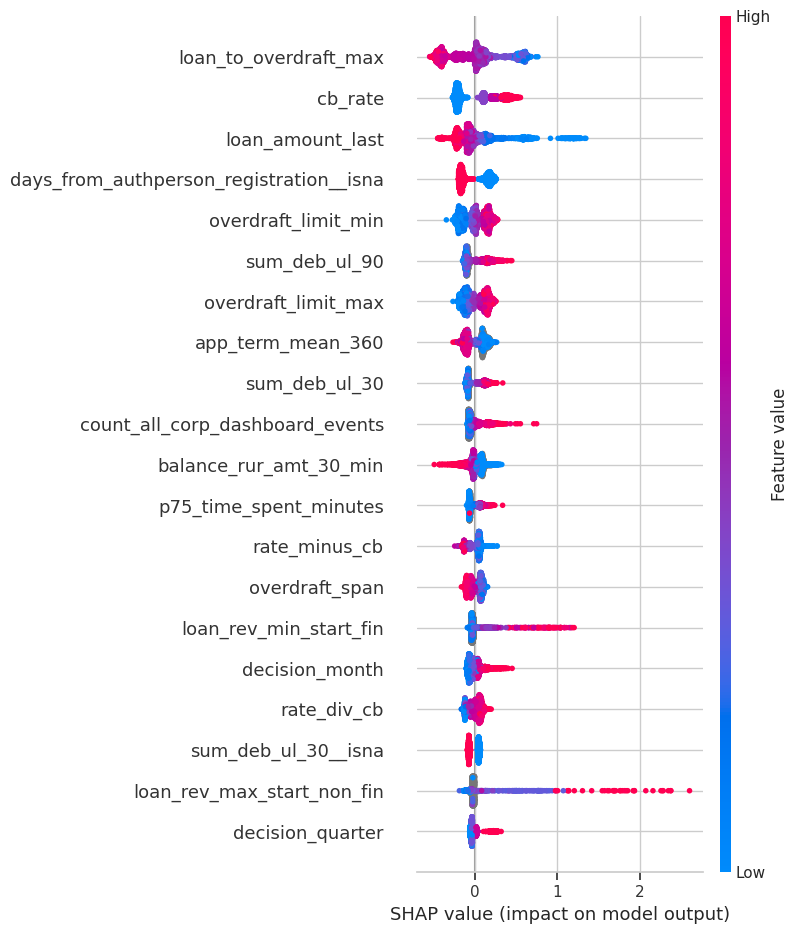

In [31]:
import shap

cat_final = CatBoostClassifier(depth=6, learning_rate=0.035, l2_leaf_reg=12,
                               iterations=1200, loss_function="Logloss", random_seed=42,
                               verbose=False, allow_writing_files=False, **cat_dev())
ci = [feats_full.index(c) for c in CAT_COLS if c in feats_full]
cat_final.fit(Pool(cbf(tr_full, feats_full), y_full, cat_features=ci))

sample = cbf(tr_full, feats_full).sample(n=4000, random_state=42)
explainer = shap.TreeExplainer(cat_final)
shap_values = explainer.shap_values(Pool(sample, cat_features=ci))

shap.summary_plot(shap_values, sample, max_display=20, show=True)

In [32]:
mean_abs = np.abs(shap_values).mean(0)
shap_imp = pd.Series(mean_abs, index=sample.columns).sort_values(ascending=False)
print("Топ-20 признаков по среднему |SHAP|:")
print(shap_imp.head(20).to_string())

Топ-20 признаков по среднему |SHAP|:
loan_to_overdraft_max                      0.260308
cb_rate                                    0.235123
loan_amount_last                           0.168121
days_from_authperson_registration__isna    0.166795
overdraft_limit_min                        0.119759
sum_deb_ul_90                              0.117345
overdraft_limit_max                        0.114992
app_term_mean_360                          0.104893
sum_deb_ul_30                              0.098395
count_all_corp_dashboard_events            0.080089
balance_rur_amt_30_min                     0.071141
p75_time_spent_minutes                     0.068897
rate_minus_cb                              0.067903
overdraft_span                             0.066255
loan_rev_min_start_fin                     0.063927
decision_month                             0.060976
rate_div_cb                                0.060792
sum_deb_ul_30__isna                        0.058311
loan_rev_max_start_non_fin 